In [20]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [21]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData,ForeignKey,Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别
from faker import Faker
import random
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,ToolMessage

# 创建基类
Base = declarative_base()

class SalesData(Base):
    __tablename__ = 'sales_data'
    sales_id = Column(Integer, primary_key=True)
    product_id= Column(Integer,ForeignKey('product_information.product_id'))
    employee_id=Column(Integer)
    customer_id=Column(Integer,ForeignKey('customer_information.customer_id'))
    sale_date=Column(String(50))
    quantity=Column(Integer)
    amount=Column(Float)
    discount=Column(Float)
    
class CustomerInformation(Base):
    __tablename__ = 'customer_information'
    customer_id=Column(Integer,primary_key=True)
    customer_name=Column(String(50))
    contact_info=Column(String(50))
    region=Column(String(50))
    customer_type=Column(String(50))
    
class ProductInformation(Base):
    __tablename__ = 'product_information'
    product_id=Column(Integer,primary_key=True)
    product_name=Column(String(50))
    category=Column(String(50))
    unit_price=Column(Float)
    stock_level=Column(Integer)
    
class CompetitorAnalysis(Base):
    __tablename__ = 'competitor_analysis'
    competitor_id=Column(Integer,primary_key=True)
    competitor_name=Column(String(50))
    region=Column(String(50))
    market_share=Column(Float)
    

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)
Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-08-28 21:12:27,077 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-28 21:12:27,078 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:12:27,080 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-28 21:12:27,082 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:12:27,084 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-28 21:12:27,086 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:12:27,089 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-28 21:12:27,090 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`sales_data`
2026-08-28 21:12:27,091 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:12:27,095 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`customer_information`
2026-08-28 21:12:27,096 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:12:27,100 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`product_information`
2026-08-28 21:12:27,101 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-28 21:

In [22]:
from pydantic import BaseModel,Field
from langchain_core.tools import tool
from typing import List, Union,Optional

class AddSaleSchema(BaseModel):
    product_id:int
    employee_id:int
    customer_id:int
    sale_date:str
    quantity:int
    amount:float
    discount:float
    
class DeleteSaleSchema(BaseModel):
    sales_id:int

class UpdateSaleSchema(BaseModel):
    sales_id:int
    quantity:int
    amount:float

class QuerySalesSchema(BaseModel):
    sales_ids:List[int]
    
 

@tool(args_schema=AddSaleSchema)
def add_sale(product_id,employee_id,customer_id,sale_date,quantity,amount,discount):
    """Add sale record to the database"""
    session=Session()
    try:
        new_sale=SalesData(
            product_id=product_id,
            employee_id=employee_id,
            customer_id=customer_id,
            sale_date=sale_date,
            quantity=quantity,
            amount=amount,
            discount=discount
        )
        session.add(new_sale)
        session.commit()
        return {"messages":["销售记录添加成功。"]}
    except Exception as e:
        return {"messages":[f"添加失败，错误原因：{e}"]}
    finally:
        session.close()

@tool(args_schema=DeleteSaleSchema)
def delete_sale(sales_id):
    """Delete sale record from the database."""
    session=Session()
    try:
        sale_to_delete=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_delete:
            session.delete(sale_to_delete)
            session.commit()
            return {"messages":["销售记录删除成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"删除失败，错误原因:{e}"]}
    finally:
        session.close()
        
@tool(args_schema=UpdateSaleSchema)
def update_sale(sales_id,quantity,amount):
    """Update sale record in the database"""
    session=Session()
    try:
        sale_to_update=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_update:
            sale_to_update.quantity=quantity
            sale_to_update.amount=amount
            session.commit()
            return {"messages":["销售记录更新成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"更新失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QuerySalesSchema)
def query_sales(sales_ids):
    """Query sale record in the database"""
    session=Session()
    try:
        sale_data_list=session.query(SalesData).filter(SalesData.sales_id.in_(sales_ids)).all()
        if sale_data_list:
            result = []
            for sale_data in sale_data_list:
                result.append({
                    "sales_id": sale_data.sales_id,
                    "product_id": sale_data.product_id,
                    "employee_id": sale_data.employee_id,
                    "customer_id": sale_data.customer_id,
                    "sale_date": sale_data.sale_date,
                    "quantity": sale_data.quantity,
                    "amount": sale_data.amount,
                    "discount": sale_data.discount
                })
            return {"sales": result}
        else:
            return {"messages": [f"未找到销售记录ID:{sales_ids}"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

In [23]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
import json

repl=PythonREPL()

@tool
def python_repl(
    code:Annotated[str,"The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result=repl.run(code)
    except BaseException as e:
        return f"Failed to execute.Error: {repr(e)}"
    result_str=f"Successfully executed:\n\`\`\` python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

In [24]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langchain.agents import create_agent

db_agent=create_agent(
    llm,tools=[add_sale,delete_sale,update_sale,query_sales],
    system_prompt="""
    you use to perform database operations while should provide 
    accurate data for the code_generation agent
    """
)

code_agent=create_agent(
    llm,tools=[python_repl],
    system_prompt="""
    run python code to display diagrams or output execution results
    """
)

In [25]:
def db_node(state):
    result=db_agent.invoke(state['messages'][-1].content)
    return {'messages':[result]}

def code_node(state):
    result=code_agent.invoke(state['messages'][-1].content)
    return {'messages':[result]}

def chat(state):
    messages=state['messages']
    result=llm.invoke(messages)
    return {'messages':[result]}


In [26]:
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    next:str
    count:int

members=['chat','coder','sqler']
optinos=members+['FINISH']

In [27]:
from typing import Literal, TypedDict


class Router(TypedDict):
    """worker to route to next. If no works needed, route to FINISH"""
    next:Literal['chat','coder','sqler','FINISH']

In [28]:
def supervisor(state:AgentState):
    count = state.get('count', 0) + 1
    print('-------------------',count)
    # 兜底：超过最大轮数，强制结束，不再让 LLM 决定
    if count > 10:
        return {'next': 'FINISH', 'count': count}

    system_prompt="""
    "You are a supervisor tasked with managing a conversation between the "
            f" following workers: {members}. \n\n"
            "Each worker has a specific role: \n"
            "- chat: Responds directly to user inputs using natural language.\n"
            "- coder: Activated for tasks that require mathematical calculations or specific coding needs \n"
            "- sqler: Used when database queries or explicit SQL generation is needed.\n\n"
            "Given the following user request, respond with the worker to act next."
            " Each worker will perform a task and respond with their results and status."
            "When finished , respond with FINISH."
    """
    
    messages=[{'role':'system','content':system_prompt}]+state['messages']
    response=llm.with_structured_output(Router,method="function_calling").invoke(messages)
    return {'next':response['next'], 'count': count}

In [29]:
from langchain_core.messages import HumanMessage

def chat(state:AgentState):
    messages=state['messages']
    result=llm.invoke(messages)
    final_response=[HumanMessage(content=result.content,name="chat")]
    return {'messages':final_response}

def code_node(state:AgentState):
    result=code_agent.invoke(state)
    final_response=[HumanMessage(content=result['messages'][-1].content,name="coder")]
    return {'messages':final_response}

def db_node(state:AgentState):
    result=db_agent.invoke(state)
    final_response=[HumanMessage(content=result['messages'][-1].content,name="sqler")]
    return {'messages':final_response}

def should_contine(state:AgentState):
    next=state['next']
    if next=='chat':
        return 'chat'
    elif next=='coder':
        return 'coder'
    elif next=='sqler':
        return 'sqler'
    else:
        return 'FINISH'

In [30]:
from langgraph.graph import START, StateGraph, END


builder=StateGraph(AgentState)

builder.add_node('supervisor',supervisor)
builder.add_node('chat',chat)
builder.add_node('coder',code_node)
builder.add_node('sqler',db_node)

builder.add_edge(START,'supervisor')

builder.add_conditional_edges('supervisor',should_contine,{
    'chat':'chat',
    'coder':'coder',
    'sqler':'sqler',
    'FINISH':END,
})

builder.add_edge('chat','supervisor')
builder.add_edge('coder','supervisor')
builder.add_edge('sqler','supervisor')

graph=builder.compile()

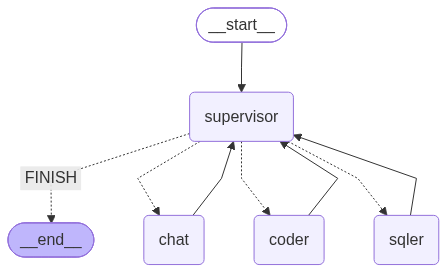

In [31]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
async for chunk in graph.astream({"messages":['我想查询数据库中销售数据 id从5 到10，生成一个柱状图']}, stream_mode="updates"):
    for node_name, updates in chunk.items():
        for m in updates.get('messages', []):
            m.pretty_print()


------------------- 1
2026-08-28 21:13:44,061 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-28 21:13:44,071 INFO sqlalchemy.engine.Engine SELECT sales_data.sales_id AS sales_data_sales_id, sales_data.product_id AS sales_data_product_id, sales_data.employee_id AS sales_data_employee_id, sales_data.customer_id AS sales_data_customer_id, sales_data.sale_date AS sales_data_sale_date, sales_data.quantity AS sales_data_quantity, sales_data.amount AS sales_data_amount, sales_data.discount AS sales_data_discount 
FROM sales_data 
WHERE sales_data.sales_id IN (%(sales_id_1_1)s, %(sales_id_1_2)s, %(sales_id_1_3)s, %(sales_id_1_4)s, %(sales_id_1_5)s, %(sales_id_1_6)s)
2026-08-28 21:13:44,072 INFO sqlalchemy.engine.Engine [cached since 69.15s ago] {'sales_id_1_1': 5, 'sales_id_1_2': 6, 'sales_id_1_3': 7, 'sales_id_1_4': 8, 'sales_id_1_5': 9, 'sales_id_1_6': 10}
2026-08-28 21:13:44,074 INFO sqlalchemy.engine.Engine ROLLBACK
================================ Human Message ===================